# 🏎️ GP Canadá 2026 — ¿Quién chocará contra el Muro de los Campeones?
### Regresión Logística con datos reales de FastF1

**Lógica del modelo:**
1. **Entrenamos** con datos históricos reales de Canadá (2018–2024): métricas de telemetría de cada piloto y si acabó chocando o no.
2. **Predecimos** usando la telemetría real de 2026 (Miami, Japón, China, Australia).

Variables que usamos:
- `inconsistencia`: desviación estándar de tiempos de vuelta → piloto errático = más riesgo
- `abandono`: si no terminó alguna carrera este año
- `velocidad_max`: velocidad punta media (el circuito de Montreal premia la velocidad punta pero castiga los errores de frenada)

---
## CELDA 1 — Instalación y librerías

In [1]:
# Ejecuta esto una sola vez si no tienes las librerías
# !pip install fastf1 scikit-learn pandas numpy matplotlib

import fastf1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

fastf1.Cache.enable_cache('./f1_cache')  # Crea una carpeta local para no recargar datos
print('✅ Todo listo')

✅ Todo listo


---
## CELDA 2 — Función auxiliar: extraer métricas de una sesión

Esta función recibe una sesión de FastF1 y devuelve, para cada piloto:
- Su inconsistencia en tiempos de vuelta
- Su velocidad punta media
- Si terminó o no la carrera

In [2]:
def extraer_metricas(sesion):
    """Devuelve un DataFrame con métricas por piloto para una sesión dada."""
    laps = sesion.laps
    filas = []

    for driver in laps['Driver'].unique():
        vueltas = laps.pick_driver(driver).pick_quicklaps().copy()

        if len(vueltas) < 5:
            continue

        # Tiempo de vuelta en segundos
        vueltas['Segundos'] = vueltas['LapTime'].dt.total_seconds()

        # Métrica 1: inconsistencia
        inconsistencia = vueltas['Segundos'].std()

        # Métrica 2: velocidad punta media (de la telemetría)
        try:
            tel = vueltas.get_telemetry()
            velocidad_max = tel['Speed'].quantile(0.95)  # Percentil 95 para evitar outliers
        except Exception:
            velocidad_max = np.nan

        # Métrica 3: ¿terminó la carrera?
        resultado = sesion.results[sesion.results['Abbreviation'] == driver]['Status']
        no_termino = 0
        if not resultado.empty:
            estado = str(resultado.values[0]).lower()
            if any(w in estado for w in ['accident', 'retired', 'collision', 'damage', 'dnf']):
                no_termino = 1

        filas.append({
            'piloto':        driver,
            'inconsistencia': inconsistencia,
            'velocidad_max':  velocidad_max,
            'abandono':       no_termino
        })

    return pd.DataFrame(filas)

print('✅ Función definida')

✅ Función definida


---
## CELDA 3 — Datos de entrenamiento: Canadá histórico (2018–2024)

Cargamos las carreras pasadas en Montreal. Para cada piloto y cada año, extraemos sus métricas
y etiquetamos si sufrió un incidente (`choque = 1`) o no (`choque = 0`).

**Esto es lo que hace el modelo REAL:** aprende qué combinación de métricas
estuvo asociada a incidentes reales en este circuito.

In [3]:
AÑOS_HISTORICOS = [2018, 2019, 2021, 2022, 2023, 2024]  # 2020 cancelado por COVID

datos_historicos = []

for año in AÑOS_HISTORICOS:
    print(f'⏳ Cargando Canadá {año}...')
    try:
        s = fastf1.get_session(año, 'Canada', 'R')
        s.load(telemetry=True, weather=False, messages=False)

        df_año = extraer_metricas(s)
        df_año['año'] = año
        datos_historicos.append(df_año)
        print(f'  ✅ {año}: {len(df_año)} pilotos, {df_año["abandono"].sum()} incidentes')
    except Exception as e:
        print(f'  ❌ {año}: {e}')

df_historico = pd.concat(datos_historicos, ignore_index=True)

print(f'\n📊 Total de registros para entrenamiento: {len(df_historico)}')
print(f'   Incidentes reales: {df_historico["abandono"].sum()} ({df_historico["abandono"].mean()*100:.0f}%)')
df_historico.head(10)

⏳ Cargando Canadá 2018...


core           INFO 	Loading data for Canadian Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Driver 5 completed the race distance 00:00.044000 before the recorded end of the session.
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
core           INFO 	Finished loading data for 20 drivers: ['5', '77', '33', '3', '44', '7', '27', '55', '31', '16', '10', '8', '20', '11', '9', '2', '35', '14', '28', '18']
core           INFO 	Loading data for Canadian Grand Prix - Race [v3.8.3]

  ✅ 2018: 18 pilotos, 0 incidentes
⏳ Cargando Canadá 2019...


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Driver 5 completed the race distance 00:00.190000 before the recorded end of the session.
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
core           INFO 	Finished loading data for 20 drivers: ['44', '5', '16', '77', '33', '3', '27', '10', '18', '26', '55', '11', '99', '8', '7', '63', '20', '88', '23', '4']


  ✅ 2019: 20 pilotos, 1 incidentes
⏳ Cargando Canadá 2021...


...

req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Fixed incorrect tyre stint information for driver '22'
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
core           INFO 	Finished loading data for 20 drivers: ['1', '14', '44', '16', '55', '11', '23', '31', '18', '77', '81', '10', '4', '22', '27', '24', '20', '21', '63', '2']


  ✅ 2023: 20 pilotos, 2 incidentes
⏳ Cargando Canadá 2024...


core           INFO 	Loading data for Canadian Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
core           INFO 	Finished loading data for 20 drivers: ['1', '4', '63', '44', '81', '14', '18', '3', '10', '31', '27', '20', '77', '22', '24', '55', '23', '11', '16', '2']


  ✅ 2024: 20 pilotos, 5 incidentes

📊 Total de registros para entrenamiento: 117
   Incidentes reales: 10 (9%)


,piloto,inconsistencia,velocidad_max,abandono,año
0,VET,0.692971,306.000000,0,2018
1,BOT,0.768666,306.000000,0,2018
2,VER,0.926232,301.492084,0,2018
3,RIC,0.923194,304.000000,0,2018
4,HAM,0.907118,308.147916,0,2018
5,RAI,0.909441,308.004583,0,2018
6,HUL,0.765239,300.000000,0,2018
7,SAI,0.749739,305.806873,0,2018
8,OCO,0.790790,310.000000,0,2018
9,LEC,0.976623,305.000000,0,2018


---
## CELDA 4 — Entrenar la Regresión Logística

La regresión logística aprende qué combinación de `inconsistencia` y `velocidad_max`
predijo incidentes reales en Montreal. No inventamos nada: aprendemos del pasado.

In [4]:
# Preparar datos (eliminar filas con NaN)
features = ['inconsistencia', 'velocidad_max']
df_train = df_historico.dropna(subset=features + ['abandono']).copy()

X_train = df_train[features].values
y_train = df_train['abandono'].values

# Escalar: importante para que las dos variables tengan el mismo peso
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Entrenar el modelo
modelo = LogisticRegression()
modelo.fit(X_train_scaled, y_train)

# Precisión sobre los datos de entrenamiento (orientativa)
precision = modelo.score(X_train_scaled, y_train)
print(f'✅ Modelo entrenado con {len(X_train)} registros reales de Montreal')
print(f'   Precisión en entrenamiento: {precision*100:.1f}%')
print(f'   Coeficientes: inconsistencia={modelo.coef_[0][0]:.3f}, velocidad={modelo.coef_[0][1]:.3f}')

✅ Modelo entrenado con 117 registros reales de Montreal
   Precisión en entrenamiento: 92.3%
   Coeficientes: inconsistencia=0.583, velocidad=0.520


---
## CELDA 5 — Datos de predicción: temporada 2026

Ahora cargamos las carreras de 2026 para obtener las métricas actuales de cada piloto.
Estos son los datos "frescos" con los que el modelo va a predecir.

In [5]:
CARRERAS_2026 = ['Australia', 'China', 'Japan', 'Miami']

datos_2026 = []

for gp in CARRERAS_2026:
    print(f'⏳ Cargando {gp} 2026...')
    try:
        s = fastf1.get_session(2026, gp, 'R')
        s.load(telemetry=True, weather=False, messages=False)
        df_gp = extraer_metricas(s)
        df_gp['gp'] = gp
        datos_2026.append(df_gp)
        print(f'  ✅ {gp} cargado: {len(df_gp)} pilotos')
    except Exception as e:
        print(f'  ❌ {gp}: {e}')

df_2026 = pd.concat(datos_2026, ignore_index=True)

# Agregar por piloto: media de sus métricas en toda la temporada
df_pred = df_2026.groupby('piloto').agg(
    inconsistencia=('inconsistencia', 'mean'),
    velocidad_max =('velocidad_max',  'mean'),
    incidentes    =('abandono',       'sum')
).reset_index()

print(f'\n✅ Pilotos con datos 2026: {len(df_pred)}')
df_pred.sort_values('inconsistencia', ascending=False).head(10)

core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info


⏳ Cargando Australia 2026...


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 81)
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 27)
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
core           INFO 	Finished loading data for 22 drivers: ['63', '12', '16', '44', '1', '3', '87', '41', '5', '10', '31', '23', '30', '43', '55', '11', '18', '14', '77', '6', '81', '27']
core           INFO 	Loading data for Chinese Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	U

  ✅ Australia cargado: 20 pilotos
⏳ Cargando China 2026...


core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 81)
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 1)
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 5)
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 23)
core        WARNING 	Driver 12 completed the race distance 00:00.022000 before the recorded end of the session.
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
core           INFO 	Finished loading data for 22 drivers: ['12', '63', '44', '16', '87', '10', '30', '6', '55', '43', '27', '41', '77', '31', '11', '3', '14', '18', '81', '1', '5', '23']
core           INFO 	Loading data for Japanese Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info


...

req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
core           INFO 	Finished loading data for 22 drivers: ['12', '81', '16', '63', '1', '44', '10', '3', '30', '31', '27', '6', '5', '41', '55', '43', '11', '14', '77', '23', '18', '87']
core           INFO 	Loading data for Miami Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data


  ✅ Japan cargado: 22 pilotos
⏳ Cargando Miami 2026...


req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Driver 12 completed the race distance 00:00.027000 before the recorded end of the session.
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
core           INFO 	Finished loading data for 22 drivers: ['12', '1', '81', '63', '3', '44', '43', '16', '55', '23', '87', '5', '31', '41', '14', '11', '18', '77', '27', '30', '10', '6']


  ✅ Miami cargado: 18 pilotos

✅ Pilotos con datos 2026: 22


,piloto,inconsistencia,velocidad_max,incidentes
5,BOT,1.362172,311.750000,1
13,LIN,1.231508,318.000000,0
10,HUL,1.167420,312.912499,0
2,ANT,1.085724,316.750000,0
6,COL,1.059168,318.119662,0
14,NOR,1.035917,316.684705,0
7,GAS,1.030649,320.000000,0
11,LAW,1.021490,315.998333,0
1,ALO,0.996613,304.358401,2
18,RUS,0.995400,320.193547,0


---
## CELDA 6 — Predicción para el GP de Canadá 2026

Aplicamos el modelo entrenado con datos históricos de Montreal
a las métricas actuales de cada piloto.

In [6]:
df_pred_clean = df_pred.dropna(subset=features).copy()

X_pred = df_pred_clean[features].values
X_pred_scaled = scaler.transform(X_pred)  # Usamos el mismo scaler del entrenamiento

# Probabilidad de incidente (columna [1] = probabilidad de clase 1 = choque)
df_pred_clean['prob_choque'] = modelo.predict_proba(X_pred_scaled)[:, 1]

df_pred_clean = df_pred_clean.sort_values('prob_choque', ascending=False).reset_index(drop=True)

print('🎯 PREDICCIÓN — PROBABILIDAD DE INCIDENTE EN CANADÁ 2026')
print('=' * 55)
for _, row in df_pred_clean.iterrows():
    barra = '█' * int(row['prob_choque'] * 20)
    print(f"  {row['piloto']:<6} {barra:<20} {row['prob_choque']*100:.1f}%")

🎯 PREDICCIÓN — PROBABILIDAD DE INCIDENTE EN CANADÁ 2026
  LIN    █████████            46.7%
  GAS    ████████             41.9%
  RUS    ████████             40.6%
  COL    ███████              37.9%
  ANT    ███████              35.4%
  BOT    ███████              35.2%
  NOR    ██████               32.7%
  LAW    ██████               30.3%
  SAI    █████                29.4%
  HUL    █████                29.0%
  VER    █████                28.9%
  OCO    █████                28.5%
  LEC    █████                27.8%
  BEA    █████                27.5%
  BOR    █████                25.3%
  ALB    ████                 24.0%
  HAM    ████                 22.1%
  PIA    ███                  19.9%
  PER    ███                  17.8%
  HAD    ██                   13.1%
  ALO    █                    9.1%
  STR    █                    7.0%


---
## CELDA 7 — Gráfica final para el vídeo

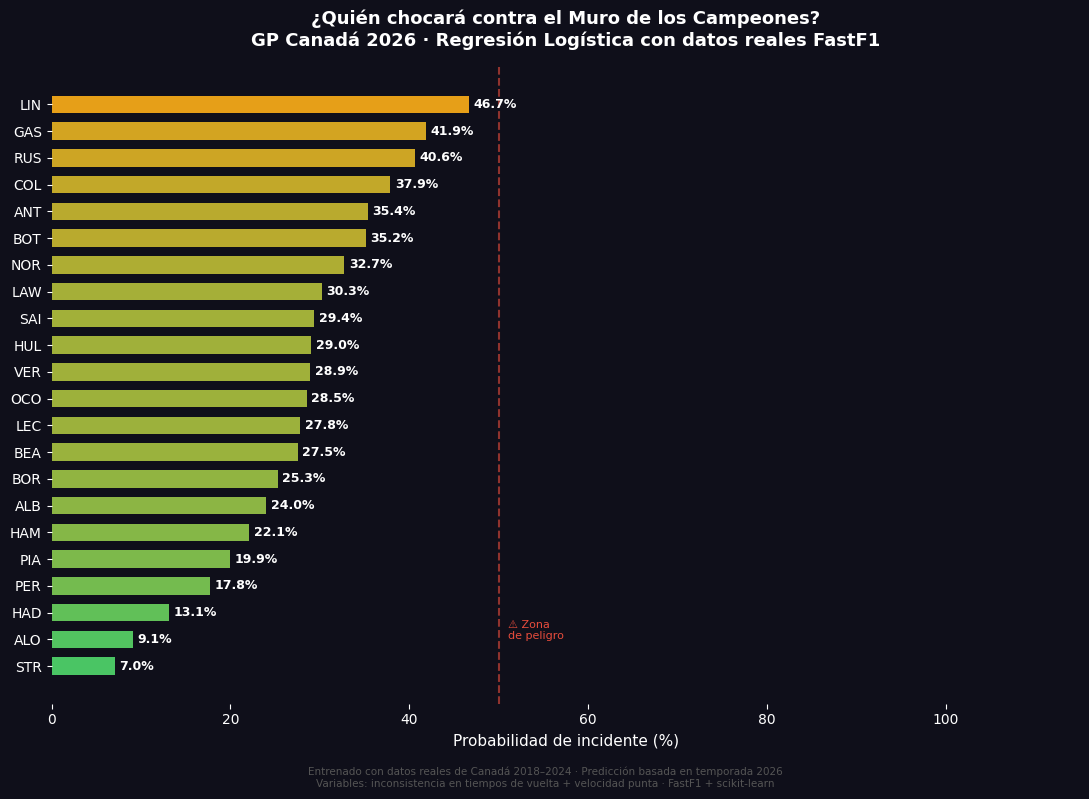

✅ Gráfica guardada como muro_campeones_logistica.png


In [7]:
df_plot = df_pred_clean.sort_values('prob_choque', ascending=True)

cmap    = LinearSegmentedColormap.from_list('riesgo', ['#2ecc71', '#f39c12', '#e74c3c'])
colores = [cmap(v) for v in df_plot['prob_choque']]

fig, ax = plt.subplots(figsize=(11, 8))
fig.patch.set_facecolor('#0f0f1a')
ax.set_facecolor('#0f0f1a')

barras = ax.barh(df_plot['piloto'], df_plot['prob_choque'] * 100,
                 color=colores, height=0.65, edgecolor='none')

# Etiquetas de porcentaje
for b, v in zip(barras, df_plot['prob_choque']):
    ax.text(b.get_width() + 0.5, b.get_y() + b.get_height() / 2,
            f'{v*100:.1f}%', va='center', color='white', fontsize=9, fontweight='bold')

# Línea de peligro al 50%
ax.axvline(x=50, color='#e74c3c', linestyle='--', alpha=0.6, linewidth=1.5)
ax.text(51, 1, '⚠️ Zona\nde peligro', color='#e74c3c', fontsize=8)

ax.set_xlim(0, 115)
ax.set_xlabel('Probabilidad de incidente (%)', color='white', fontsize=11)
ax.set_title('¿Quién chocará contra el Muro de los Campeones?\n'
             'GP Canadá 2026 · Regresión Logística con datos reales FastF1',
             color='white', fontsize=13, fontweight='bold', pad=15)
ax.tick_params(colors='white')
ax.spines[:].set_visible(False)
for label in ax.get_yticklabels():
    label.set_color('white')
    label.set_fontsize(10)

fig.text(0.5, 0.01,
         'Entrenado con datos reales de Canadá 2018–2024 · Predicción basada en temporada 2026\n'
         'Variables: inconsistencia en tiempos de vuelta + velocidad punta · FastF1 + scikit-learn',
         ha='center', color='#555555', fontsize=7.5)

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig('muro_campeones_logistica.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print('✅ Gráfica guardada como muro_campeones_logistica.png')